# Project: Investigate a Dataset - Medical Appointment No Shows

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

<a id='dataset'></a>
### Dataset Description 

We will be analyzing a dataset containing information about medical appointments made between Nov 10, 2015 and June 8, 2016 in the city of Vitória, Brazil, with the aim of identifying factors that may correlate with missed appointments.

The dataset was sourced from [Kaggle: Medical Appointment No Shows](https://www.kaggle.com/datasets/joniarroba/noshowappointments). It contains data on 100K+ medical appointments with information about each appointment and the patient. For this analysis, some columns have been renamed for clarity.

| column name | description | original name |
|---|---|---|
| `PatientId` | unique identifier for each patient |`PatientId`|
| `AppointmentId` | unique identifier for each appointment |`AppointmentID`|
| `Gender` | Male or Female |`Gender`|
| `SchedulingDate` | date the appointment was created - [reference](https://www.kaggle.com/datasets/joniarroba/noshowappointments/discussion/340475) |`ScheduledDay`|
| `AppointmentDate` | date of the appointment - [reference](https://www.kaggle.com/datasets/joniarroba/noshowappointments/discussion/340475) |`AppointmentDay`|
| `Age` | age of the patient |`Age`|
| `Neighborhood` | neighborhood of Vitória, Brazil where the appointment takes place |`Neighbourhood`|
| `FinancialAssistance` | patient enrolled in [Bolsa Família](https://en.wikipedia.org/wiki/Bolsa_Fam%C3%ADlia) financial assistance program |`Scholarship`|
| `Hypertension` | patient diagnosed with hypertension |`Hipertension`|
| `Diabetes` | patient diagnosed with diabetes |`Diabetes`|
| `Alcoholism` | patient diagnosed with alcoholism |`Alcoholism`|
| `NumHandicaps` | number of handicaps - [reference](https://www.kaggle.com/datasets/joniarroba/noshowappointments/discussion/29699#229356) |`Handcap`|
| `SMS_received` | 1 or more text messages were sent to the patient |`SMS_received`|
| `NoShow` | the patient missed the appointment |`No-show`|

#### Expanded Dataset
Additional columns have been added to the dataset, derived from the existing data
| column name | description | derived from |
| --- | --- | --- |
| `SchedulingDate_day_name` | day of week the appointment was created | `SchedulingDate` |
| `AppointmentDate_day_name` | day of week of the appointment | `AppointmentDate` |
| `num_days` | number of days elapsed between appointment creation and appointment | `SchedulingDate` and `AppointmentDate` |
| `num_patient_appointments` | number of appointments a patient has scheduled | count of rows with the same `PatientId` |
| `num_patient_NoShow` | number of appointments a patient has missed | count of `NoShow` per `PatientId` |


### Question(s) for Analysis
- Do patient demographic or health factors correlate to a higher likelihood of missing an appointment?
- Do factors related to the appointment itself correlate to a higher likelihood of a missed appointment?

<a id='wrangling'></a>
## Data Wrangling

### Environment Setup

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm;
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import math

%config InlineBackend.figure_format = 'svg'
%matplotlib inline

def value_range(data: pd.Dataframe, column: str) -> str:
    x = data[column]
    return f"{column}:\n{"min":<8}{"max"}\n{x.min():<8}{x.max()}\n"
    # return f"{column}\n  min:{x.min()}\n  max:{x.max()}"


### General Properties
- 110527 records found
- no empty fields found

In [ ]:
base_df = pd.read_csv(
    "./Database_No_show_appointments/noshowappointments-kagglev2-may-2016.csv"
)

base_df = base_df.convert_dtypes()

print(f"rows: {base_df.shape[0]}")
print(f"any na?: {base_df.isna().sum().any()}")
print(f"any null?: {base_df.isnull().sum().any()}\n")

print(base_df.info())

### Data Cleaning
#### Column naming
Renaming columns for clarity - [see Dataset Description](#dataset) for more info
- `AppointmentID` --> `AppointmentId` for consistency
- `ScheduledDay` --> `SchedulingDate` to better reflect data type
- `AppointmentDay` --> `AppointmentDate` for clarity and to reflect data type
- `Neighbourhood` --> `Neigborhood` (US English spelling)
- `Scholarship` --> `FinancialAssistance` for clarity
- `Hipertension` --> `Hypertension` (US English spelling)
- `Handcap` --> `NumHandicaps` for clarity
- `No-show` --> `NoShow` for consitency and Python compatibility

In [ ]:
base_df.rename(
    columns={
        "AppointmentID": "AppointmentId",
        "ScheduledDay": "SchedulingDate",
        "AppointmentDay": "AppointmentDate",
        "Neighbourhood": "Neighborhood",
        "Scholarship": "FinancialAssistance",
        "Hipertension": "Hypertension",
        "Handcap": "NumHandicaps",
        "No-show": "NoShow",
    },
    inplace=True,
)

#### AppointmentId
- no duplicate `AppointmentId`s found
- `AppointmentId` set as the DataFrame index

In [ ]:
print(f"duplicate AppointmentIds: {base_df['AppointmentId'].duplicated().sum()}\n")
base_df.set_index("AppointmentId", inplace=True)

#### Gender
- 2 values found in data: `["F", "M"]` 
- `Gender` converted to categorical datatype `["female", "male"]`

In [ ]:
print(base_df["Gender"].unique())

base_df["Gender"] = base_df["Gender"].map({"F": "female", "M": "male"})
gender_categories = base_df["Gender"].unique()

gender_category = pd.api.types.CategoricalDtype(
    ordered=False, categories=gender_categories
)

base_df["Gender"] = base_df["Gender"].astype(gender_category)
print()
print(base_df["Gender"].unique())

#### SchedulingDate and AppointmentDate
- `SchedulingDate` and `AppointmentDate` converted to `datetime` datatype
- time of day not recorded for `AppointmentDate`
- time of day was recorded for `SchedulingDate`, but for our purposes this is not interesting information. `SchedulingDate` time of day has been erased to enable like-for-like comparison to `AppointmentDate`
- `SchedulingDate_day_name` and `AppointmentDate_day_name` were derived from appointment data and added to dataset
- `num_days` was derived from appointment data and added to dataset
- appointments with a negative `num_days` value are considered invalid and have been removed

In [ ]:
base_df["SchedulingDate"] = pd.to_datetime(
    base_df["SchedulingDate"]
).dt.normalize()  # time of day information removed

base_df["AppointmentDate"] = pd.to_datetime(base_df["AppointmentDate"])

# SchedulingDate - day of week
base_df["SchedulingDate_day_name"] = base_df["SchedulingDate"].dt.day_name()

# AppointmentDate - day of week
base_df["AppointmentDate_day_name"] = base_df["AppointmentDate"].dt.day_name()

# number of days: SchedulingDate -> AppointmentDate
base_df["num_days"] = (base_df["AppointmentDate"] - base_df["SchedulingDate"]).dt.days

print(value_range(data=base_df, column="num_days"))
base_df["num_days"] = base_df["num_days"].astype(np.int16)

# removing appointments with invalid dates
before = base_df.shape[0]
base_df = base_df[base_df["num_days"] >= 0]
after = base_df.shape[0]

print(f"dropped {before - after} row(s) with bad timestamps")

#### Age
- Droped rows with invalid Age values `Age < 0`
- `Age == 0` assumed to be an infant
- right-sized datatype

In [ ]:
print(value_range(base_df, "Age"))

before = base_df.shape[0]
base_df = base_df[base_df["Age"] >= 0]
after = base_df.shape[0]
base_df["Age"] = base_df["Age"].astype(np.int8)

print(f"dropped {before - after} row(s) with invalid ages")

#### Neighborhood

- 81 unique neighborhoods
- converted to categorical datatype

In [ ]:
print(f"unique neighborhoods: {base_df['Neighborhood'].nunique()}")
neighborhood_categories = base_df["Neighborhood"].unique()

neighborhood_category = pd.api.types.CategoricalDtype(
    ordered=False, categories=neighborhood_categories
)

base_df["Neighborhood"] = base_df["Neighborhood"].astype(neighborhood_category)

##### Encoded Booleans
Converted binary columns (`[0,1]`, `["Yes","No"]`) to boolean
- `FinancialAssistance`,
- `Hypertension`,
- `Diabetes`,
- `Alcoholism`,
- `SMS_received`,
- `NoShow`

In [ ]:
print(f"{base_df["FinancialAssistance"].value_counts()}")
base_df["FinancialAssistance"] = base_df["FinancialAssistance"].astype("boolean")

print(f"{base_df["Hypertension"].value_counts()}")
base_df["Hypertension"] = base_df["Hypertension"].astype("boolean")

print(f"{base_df["Diabetes"].value_counts()}")
base_df["Diabetes"] = base_df["Diabetes"].astype("boolean")

print(f"{base_df["Alcoholism"].value_counts()}")
base_df["Alcoholism"] = base_df["Alcoholism"].astype("boolean")

print(f"{base_df["SMS_received"].value_counts()}")
base_df["SMS_received"] = base_df["SMS_received"].astype("boolean")

print(f"{base_df["NoShow"].value_counts()}")
base_df["NoShow"] = base_df["NoShow"].map({"Yes": True, "No": False}).astype("boolean")

#### numHandcap
- right-size datatype to value range
- no other changes necessary

In [ ]:
print(value_range(base_df, "NumHandicaps"))
print(base_df["NumHandicaps"].value_counts())
base_df["NumHandicaps"] = base_df["NumHandicaps"].astype(np.int8)

<a id='patientid'></a>
#### PatientId

Out of 110,521 appointments, there are 62298 unique `PatientId` values, indicating there are a large number of patients with multiple appointments.

- The number of appointments per `PatientId` ranges between 1 and 88
- The number of no-show appointments per `PatientId` ranges between 0 and 18
- To simplify later analysis, `num_patient_appointments` and `num_patient_NoShow` are derived from existing data and added to the dataset for each patient.

Appointments with duplicated `PatientId` were further examined for inconsistencies, and no differences were found across these demographic data points:
- `Gender`
- `Hypertension`
- `Diabetes`
- `Alcoholism`
- `numHandicaps`
- `Neighborhood`
- `FinancialAssistance`

With these considerations, it will be safe to filter out appointments with duplicate `PatientId`s when examining patient demographic information.

In [ ]:
print(f"appointments: {base_df.shape[0]}")
print(f"unique PatientIds: {base_df['PatientId'].nunique()}")
print(f"rows with duplicated PatientIds: {base_df['PatientId'].duplicated().sum()}\n")

base_df["num_patient_appointments"] = base_df.groupby("PatientId")["PatientId"].transform("size").astype(np.int8)
base_df["num_patient_NoShow"] = base_df.groupby("PatientId")["NoShow"].transform("sum").astype(np.int8)

print(value_range(base_df, "num_patient_appointments"))
print(value_range(base_df, "num_patient_NoShow"))

print(
    f"\nduplicate PatientIds considering demographic factors: {base_df.duplicated(subset=[
        "PatientId",
        "Gender",
        "Hypertension",
        "Diabetes",
        "Alcoholism",
        "NumHandicaps",
        "Neighborhood",
        "FinancialAssistance"
        ]).sum()}"
)


#### Data Cleanup results

In [ ]:
print(base_df.info())
base_df.head()

<a id='eda'></a>
## Exploratory Data Analysis

> **Tip**: Now that you've trimmed and cleaned your data, you're ready to move on to exploration. **Compute statistics** and **create visualizations** with the goal of addressing the research questions that you posed in the Introduction section. You should compute the relevant statistics throughout the analysis when an inference is made about the data. Note that at least two or more kinds of plots should be created as part of the exploration, and you must  compare and show trends in the varied visualizations. Remember to utilize the visualizations that the pandas library already has available.



> **Tip**: Investigate the stated question(s) from multiple angles. It is recommended that you be systematic with your approach. Look at one variable at a time, and then follow it up by looking at relationships between variables. You should explore at least three variables in relation to the primary question. This can be an exploratory relationship between three variables of interest, or looking at how two independent variables relate to a single dependent variable of interest. Lastly, you  should perform both single-variable (1d) and multiple-variable (2d) explorations.


### Data preparation for linear and logistical regression analysis

In [ ]:
# create full rank dataframe
df_all_appointments = base_df.copy()

# booleans
df_all_appointments["FinancialAssistance"] = df_all_appointments[
    "FinancialAssistance"
].astype(int)
df_all_appointments["Hypertension"] = df_all_appointments["Hypertension"].astype(np.int8)
df_all_appointments["Diabetes"] = df_all_appointments["Diabetes"].astype(np.int8)
df_all_appointments["Alcoholism"] = df_all_appointments["Alcoholism"].astype(np.int8)
df_all_appointments["SMS_received"] = df_all_appointments["SMS_received"].astype(np.int8)
df_all_appointments["NoShow"] = df_all_appointments["NoShow"].astype(np.int8)

# create dummies for categorical datatypes
gender_dummies = pd.get_dummies(base_df["Gender"], dtype=np.int8)
nhood_dummies = pd.get_dummies(base_df["Neighborhood"], dtype=np.int8)
schedulingDay_dummies = pd.get_dummies(
    base_df["SchedulingDate_day_name"], prefix="sch", dtype=np.int8
)
appointDay_dummies = pd.get_dummies(
    base_df["AppointmentDate_day_name"], prefix="apt", dtype=np.int8
)
df_all_appointments = df_all_appointments.join(
    [gender_dummies, nhood_dummies, schedulingDay_dummies, appointDay_dummies]
)

df_all_appointments["intercept"] = 1

### Utility functions

In [73]:
def significant_predictors(results, alpha=0.05) -> str:
    result = ""
    p_values = results.pvalues
    for _ in np.arange(1, len(p_values.index)):
        if p_values.values[_] < alpha:
            result = result + f"{p_values.index[_]:<24}{p_values.values[_]:.6f}\n"

    result = (
        "\nsignificant predictors: None"
        if result == ""
        else "\nsignificant predictors\n" + result
    )

    return result

def compute_distributions(
    data: pd.DataFrame, base_query: str = None, queries: dict[str, str] = {}
) -> dict[str, list[float]]:
    base = data if base_query == None else data.query(base_query)
    num_base = base.shape[0]

    result = {"All Patients": num_base / data.shape[0]}

    for q in queries.keys():
        result[q] = base.query(queries[q]).shape[0] / num_base

    return result

# data = paramName: { "all": {...}, "noshow": {...}, "show": {...}}
def graph_distributions(
    data: dict[str, dict[str, float]], group_names: list[str]
) -> tuple[plt.Figure, plt.Axes]:
    fig_height = round(len(group_names) * 1.5)

    bar_container_heights = {
        d_name: tuple(d[g] for g in group_names) for d_name, d in data.items()
    }

    fig, ax = plt.subplots(figsize=(7, fig_height))
    bar_containers = ax.grouped_bar(
        heights=bar_container_heights,
        tick_labels=group_names,
        group_spacing=1,
        orientation="horizontal",
    );

    for container in bar_containers.bar_containers:
        ax.bar_label(
            container, fmt=lambda x: f"{x * 100:.1f}%", label_type="edge", padding=3
        )

    ax.set_xlabel("% of all Patients")
    ax.legend(loc="upper right", ncols=1)
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
    ax.tick_params(labelsize="small")
    ax.tick_params("y", labelrotation=90, labelrotation_mode="ytick")

    return (fig, ax)

### Do any of a patient's demographic or health factors correlate to a higher likelihood of a missed appointment?

In this section of our analysis we intend to compare patients. To do this we need to collapse multiple appointments made by a patient into a single item.

All of the demographic factors we are analyzing remain constant across all of a patients appointments - _[see Data Cleaning/PatientId](#patientid)_. Whether they are a "no-show" for a given appointment can vary however, as well as the number of appointments a patient had scheduled within the dataset's timeframe. To address this we will use the proportion of a patient's no-show appointments (`num_patient_NoShow`) to the total number of appointments they have scheduled (`num_patient_appointments`) as our measurment of a patient's Show/NoShow behavior.

$$\text{p\_NoShow} = \frac{\text{num\_patient\_NoShow}}{\text{num\_patient\_appointments}}$$

#### Patient demographic and health factors
- `Gender`
- `Age`
- `Neighborhood`
- `FinancialAssistance`
- `Hypertension`
- `Diabetes`
- `Alcoholism`
- `NumHandicaps`


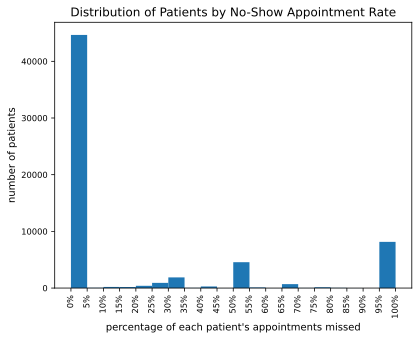

In [74]:
# calculate NoShow appointment proportion for each patient
df_all_appointments["p_NoShow"] = df_all_appointments.apply(lambda x: x.num_patient_NoShow / x.num_patient_appointments, axis=1)

# prune duplicate patientIds
df_all_patients = df_all_appointments.drop_duplicates(subset=["PatientId"])

p_NoShow_axs_bins = 20
p_NoShow_axs = df_all_patients["p_NoShow"].plot.hist(bins=p_NoShow_axs_bins, xlabel="percentage of each patient's appointments missed", ylabel="number of patients");

xticks = np.linspace(0, 1, p_NoShow_axs_bins + 1)
xlabels = [f"{x*100:.0f}%" for x in xticks]
p_NoShow_axs.tick_params(labelsize="small")
p_NoShow_axs.tick_params("x", labelrotation=90, labelrotation_mode="xtick")
p_NoShow_axs.set_xticks(xticks, labels=xlabels);
p_NoShow_axs.set_title("Distribution of Patients by No-Show Appointment Rate");


#### Gender, FinancialAssistance, Hypertension, Diabetes, Alcoholism 

In this section we looked into whether Gender, FinancialAssistance, Hypertension, Diabetes, or Alcoholism had a statistically significant correlation with missed appointments - individually or collectively.



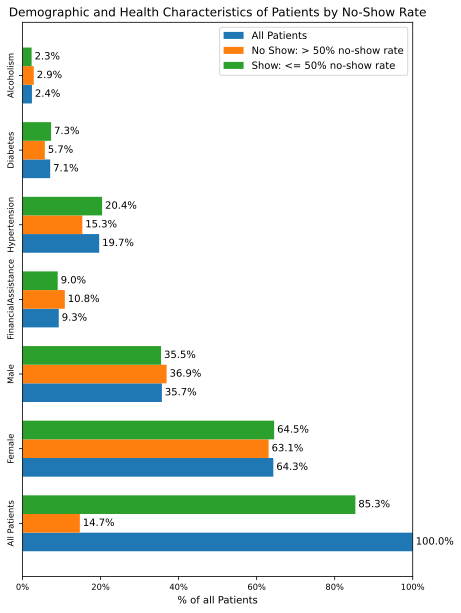

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                62298
Model:                            GLM   Df Residuals:                   110515
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -34604.
Date:                Thu, 10 Sep 2026   Deviance:                       51461.
Time:                        13:24:19   Pearson chi2:                 7.10e+04
No. Iterations:                     5   Pseudo R-squ. (CS):           0.001988
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
intercept              -2.0207    

In [ ]:
# distributions of demographic factors - excluding neighborhood

demo_queries = {
    "Female": "female == 1",
    "Male": "male == 1",
    "FinancialAssistance": "FinancialAssistance == 1",
    "Hypertension": "Hypertension == 1",
    "Diabetes": "Diabetes == 1",
    "Alcoholism": "Alcoholism == 1",
}

demo_fig, demo_axs = graph_distributions(
    data={
        "All Patients": compute_distributions(data=df_all_patients, queries=demo_queries),
        "No Show: > 50% no-show rate": compute_distributions(
            data=df_all_patients, base_query="p_NoShow > 0.5", queries=demo_queries
        ),
        "Show: <= 50% no-show rate": compute_distributions(
            data=df_all_patients, base_query="p_NoShow <= 0.5", queries=demo_queries
        ),
    },
    group_names=[
        "All Patients",
        "Female",
        "Male",
        "FinancialAssistance",
        "Hypertension",
        "Diabetes",
        "Alcoholism",
    ],
)
demo_axs.set_title("Demographic and Health Characteristics of Patients by No-Show Rate")

plt.show()

glm_model = sm.GLM(
    df_all_patients["p_NoShow"],
    df_all_patients[["intercept", "FinancialAssistance", "Hypertension", "Diabetes", "Alcoholism", "female"]],
    family=sm.families.Binomial(),
    freq_weights=df_all_patients["num_patient_appointments"]
    )

glm_results = glm_model.fit()
print(glm_results.summary())

print(significant_predictors(glm_results))

#### Neighborhood

In [ ]:
# logistic regression for neighborhood (all Patients)

# NoShow proportion per neighborhood
# 0 or 100% will be excluded from logistic regressions
nhoods = df_all_patients["Neighborhood"].unique()
nhood_no_show = pd.DataFrame({"nhood": nhoods, "pNoShow": None})
nhood_no_show.set_index("nhood", inplace=True)
nhoods_to_ignore = set()

for nhood in nhood_no_show.index:
    nhood_appointments = df_all_patients[df_all_patients["Neighborhood"] == nhood]
    num_patient_appointments = nhood_appointments.shape[0]
    num_no_shows = nhood_appointments["NoShow"].sum()

    prob_no_show = num_no_shows / num_patient_appointments

    if prob_no_show == 0 or prob_no_show == 1:
        nhoods_to_ignore.add(nhood)
        print(f"{nhood} will be ignored (pNoShow = {prob_no_show:.2%})")
        prob_no_show = None

    nhood_no_show.loc[nhood, "pNoShow"] = prob_no_show

nhood_no_show.dropna(inplace=True)

# remove rows with visits to ignored neighborhoods
df_all_patients_clean = df_all_patients[
    ~df_all_patients["Neighborhood"].isin(nhoods_to_ignore)
].copy()

included_neighborhoods = nhood_no_show.index.to_list()
baseline_neighborhood = included_neighborhoods[0]
predictor_neighborhoods = included_neighborhoods[1:]
print(f"baseline neighborhood: {baseline_neighborhood}")

X = df_all_patients_clean[["intercept"] + predictor_neighborhoods].astype(float)
y = df_all_patients_clean["pNoShow"].astype(float)

patient_nhood_model = sm.GLM(y, X, family=sm.families.Binomial(), freq_weights=df_all_patients_clean["num_patient_appointments"])
patient_nhood_model_results = patient_nhood_model.fit()

print(patient_nhood_model_results.summary2())
print(significant_predictors(patient_nhood_model_results))

#### Age

In [ ]:
# Age histogram - try violinplot?
df_age_all = df_all_patients["Age"]
df_age_show = df_all_patients.query("NoShow == False")["Age"]
df_age_no_show = df_all_patients.query("NoShow == True")["Age"]

print(df_all_patients["Age"].max())

maxAge = df_all_patients["Age"].max()
bins = maxAge + 1
range = (0, maxAge + 1)

figAge, ((ax_age_all, ax_age_show, ax_age_no_show)) = plt.subplots(
    nrows=3, ncols=1, figsize=(7, 9), sharey=True
)

ax_age_all.hist(x=df_age_all, histtype="bar", bins=bins, range=range, density=True)
ax_age_all.set_title("Age Distribution: All Patients")
ax_age_all.tick_params(labelsize="small")
ax_age_all.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))

ax_age_show.hist(x=df_age_show, histtype="bar", bins=bins, range=range, density=True)
ax_age_show.set_title("Age Distribution: Show Patients")
ax_age_show.tick_params(labelsize="small")

ax_age_no_show.hist(
    x=df_age_no_show, histtype="bar", bins=bins, range=range, density=True
)
ax_age_no_show.set_title("Age Distribution: No Show Patients")
ax_age_no_show.tick_params(labelsize="small")

plt.show()

# Age logistical regression

#### NumHandicaps

In [ ]:
# NumHandicaps histogram
df_handcap_all = df_all_patients["NumHandicaps"]
df_handcap_show = df_all_patients.query("NoShow == False")["NumHandicaps"]
df_handcap_no_show = df_all_patients.query("NoShow == True")["NumHandicaps"]

print(df_handcap_all.value_counts())

max_num_handcaps = df_handcap_all.max()
bins = np.arange(0.5, max_num_handcaps + 1.5, 1)
range = (0, max_num_handcaps + 1.5)

fig_num_handicaps, ((ax_handcap_all, ax_handcap_show, ax_handcap_no_show)) = (
    plt.subplots(nrows=3, ncols=1, figsize=(7, 9), sharey=True, sharex=True)
)

counts_all, bins_all, patches_all = ax_handcap_all.hist(
    x=df_handcap_all, histtype="bar", bins=bins, range=range, density=True, rwidth=0.8
)
ax_handcap_all.set_title("NumHandicaps Distribution: All Patients")
ax_handcap_all.tick_params(labelsize="small")
ax_handcap_all.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
ax_handcap_all.bar_label(
    patches_all, fmt=lambda x: f"{x * 100:.1f}%", label_type="edge"
)
ax_handcap_all.margins(y=0.1)

counts_show, bins_show, patches_show = ax_handcap_show.hist(
    x=df_handcap_show, histtype="bar", bins=bins, range=range, density=True, rwidth=0.8
)
ax_handcap_show.set_title("NumHandicaps Distribution: Show Patients")
ax_handcap_show.tick_params(labelsize="small")
ax_handcap_show.bar_label(
    patches_show, fmt=lambda x: f"{x * 100:.1f}%", label_type="edge"
)
ax_handcap_show.margins(y=0.1)

counts_no_show, bins_no_show, patches_no_show = ax_handcap_no_show.hist(
    x=df_handcap_no_show,
    histtype="bar",
    bins=bins,
    range=range,
    density=True,
    rwidth=0.8,
)
ax_handcap_no_show.set_title("NumHandicaps Distribution: No Show Patients")
ax_handcap_no_show.tick_params(labelsize="small")
ax_handcap_no_show.bar_label(
    patches_no_show, fmt=lambda x: f"{x * 100:.1f}%", label_type="edge"
)
ax_handcap_no_show.margins(0.1)

plt.show()

# NumHandicaps logistical regression

### Do any factors related to the appointment correlate with a higher likelihood of a missed appointment?

#### Appointment factors
- `SchedulingDate_day_name` - day of week
- `AppointmentDate_day_name` - day of week
- number of days between `SchedulingDate` and `AppointmentDate`
- `SMS_received`
- number of appointments per `PatientId`
- has patient previously missed an appointment?

#### SchedulingDate_day_name

In [ ]:
sch_day_dist_queries = {
    "sch_Monday": "sch_Monday == 1",
    "sch_Tuesday": "sch_Tuesday == 1",
    "sch_Wednesday": "sch_Wednesday == 1",
    "sch_Thursday": "sch_Thursday == 1",
    "sch_Friday": "sch_Friday == 1",
    "sch_Saturday": "sch_Saturday == 1",
}

graph_distributions(
    data={
        "All": compute_distributions(data=df_all_appointments, queries=sch_day_dist_queries),
        "No Show": compute_distributions(
            data=df_all_appointments,
            base_query="NoShow == True",
            queries=sch_day_dist_queries,
        ),
        "Show": compute_distributions(
            data=df_all_appointments,
            base_query="NoShow == False",
            queries=sch_day_dist_queries,
        ),
    },
    group_names=[
        "All Patients",
        "sch_Monday",
        "sch_Tuesday",
        "sch_Wednesday",
        "sch_Thursday",
        "sch_Friday",
        "sch_Saturday",
    ],
)

plt.show()

# logistic regression: schedule days
# baseline for SchedulingDate_day_name dummies: Saturday (Sunday not present in data)
schedule_day_model = sm.Logit(
    df_all_appointments["NoShow"],
    df_all_appointments[
        [
            "intercept",
            "sch_Monday",
            "sch_Tuesday",
            "sch_Wednesday",
            "sch_Thursday",
            "sch_Friday",
        ]
    ],
)
schedule_day_results = schedule_day_model.fit()

print(schedule_day_results.summary())
print(significant_predictors(schedule_day_results))

#### AppointmentDate_day_name

In [ ]:
apt_day_dist_queries = {
    "apt_Monday": "apt_Monday == 1",
    "apt_Tuesday": "apt_Tuesday == 1",
    "apt_Wednesday": "apt_Wednesday == 1",
    "apt_Thursday": "apt_Thursday == 1",
    "apt_Friday": "apt_Friday == 1",
    "apt_Saturday": "apt_Saturday == 1",
}

graph_distributions(
    data={
        "All": compute_distributions(data=df_all_appointments, queries=apt_day_dist_queries),
        "No Show": compute_distributions(
            data=df_all_appointments,
            base_query="NoShow == True",
            queries=apt_day_dist_queries,
        ),
        "Show": compute_distributions(
            data=df_all_appointments,
            base_query="NoShow == False",
            queries=apt_day_dist_queries,
        ),
    },
    group_names=[
        "All Patients",
        "apt_Monday",
        "apt_Tuesday",
        "apt_Wednesday",
        "apt_Thursday",
        "apt_Friday",
        "apt_Saturday",
    ],
)

plt.show()

# logistic regression: appointment days
# baseline for AppointmentDate_day_name: Saturday (Sunday not present in data)
appointment_day_model = sm.Logit(
    df_all_appointments["NoShow"],
    df_all_appointments[
        [
            "intercept",
            "apt_Monday",
            "apt_Tuesday",
            "apt_Wednesday",
            "apt_Thursday",
            "apt_Friday",
        ]
    ],
)
appointment_day_results = appointment_day_model.fit()

print(appointment_day_results.summary())
print(significant_predictors(appointment_day_results))

#### num_days

In [ ]:
# scatter plot

# logistic regression for num_days
num_days_model = sm.Logit(
    df_all_appointments["NoShow"], df_all_appointments[["intercept", "num_days"]]
)
num_days_results = num_days_model.fit()

print(num_days_results.summary())
print(significant_predictors(num_days_results))

#### SMS_Received

In [ ]:
# SMS_received
sms_dist_queries = {"SMS_received": "SMS_received == 1"}

graph_distributions(
    data={
        "All": compute_distributions(data=df_all_appointments, queries=sms_dist_queries),
        "No Show": compute_distributions(
            data=df_all_appointments,
            base_query="NoShow == True",
            queries=sms_dist_queries,
        ),
        "Show": compute_distributions(
            data=df_all_appointments,
            base_query="NoShow == False",
            queries=sms_dist_queries,
        ),
    },
    group_names=["All Patients", "SMS_received"],
)

plt.show()


sms_model = sm.Logit(
    df_all_appointments["NoShow"], df_all_appointments[["intercept", "SMS_received"]]
)
sms_results = sms_model.fit()

print(sms_results.summary())
print(significant_predictors(sms_results))

In [ ]:
# number of appointments per patient

In [ ]:
# has patient previously missed an appointment

In [ ]:
# Continue to explore the data to address your additional research
#   questions. Add more headers as needed if you have more questions to
#   investigate.

<a id='conclusions'></a>
## Conclusions

> **Tip**: Finally, summarize your findings and the results that have been performed in relation to the question(s) provided at the beginning of the analysis. Summarize the results accurately, and point out where additional research can be done or where additional information could be useful.

> **Tip**: Make sure that you are clear with regards to the limitations of your exploration. You should have at least 1 limitation explained clearly. 

> **Tip**: If you haven't done any statistical tests, do not imply any statistical conclusions. And make sure you avoid implying causation from correlation!

> **Tip**: Once you are satisfied with your work here, check over your report to make sure that it is satisfies all the areas of the rubric (found on the project submission page at the end of the lesson). You should also probably remove all of the "Tips" like this one so that the presentation is as polished as possible.

## Submitting your Project 

> **Tip**: Before you submit your project, you need to create a .html or .pdf version of this notebook in the workspace here. To do that, run the code cell below. If it worked correctly, you should see output that starts with `NbConvertApp] Converting notebook`, and you should see the generated .html file in the workspace directory (click on the orange Jupyter icon in the upper left).

> **Tip**: Alternatively, you can download this report as .html via the **File** > **Download as** submenu, and then manually upload it into the workspace directory by clicking on the orange Jupyter icon in the upper left, then using the Upload button.

> **Tip**: Once you've done this, you can submit your project by clicking on the "Submit Project" button in the lower right here. This will create and submit a zip file with this .ipynb doc and the .html or .pdf version you created. Congratulations!

In [ ]:
# Running this cell will execute a bash command to convert this notebook to an .html file
#!python -m nbconvert --to html Investigate_a_Dataset.ipynb